Loaded 839 NHDA polygons
0    1.703
2    1.423
4    1.632
6    1.930
8    1.870
Name: nhda_building_volume_density, dtype: float64
Saved: C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\building_nhda\nhda_building_volume_density_violin_regbez.jpg


C:\Users\agz90fk\AppData\Local\Temp\ipykernel_30448\3296279059.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


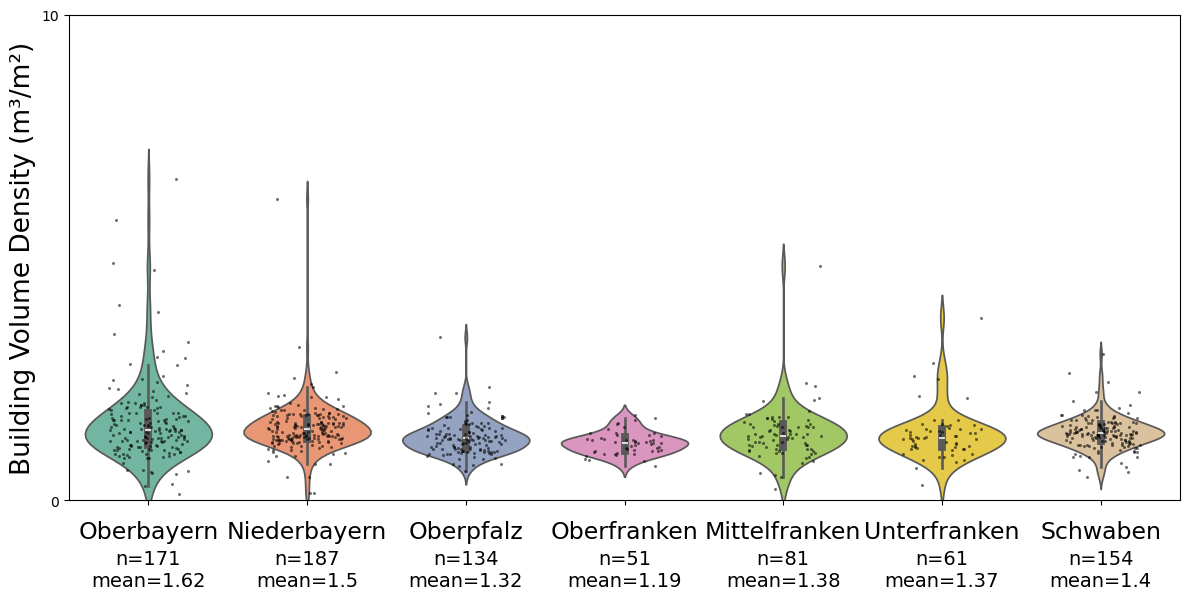


Summary statistics by Regierungsbezirk:
               count  mean   std   min   max
regbez                                      
Oberbayern       171  1.62  0.86  0.12  6.62
Niederbayern     187  1.50  0.52  0.15  6.21
Oberpfalz        134  1.32  0.36  0.60  3.36
Oberfranken       51  1.19  0.23  0.70  1.76
Mittelfranken     81  1.38  0.55  0.24  4.83
Unterfranken      61  1.37  0.53  0.32  3.77
Schwaben         154  1.40  0.34  0.48  3.02

Overall summary (all NHDAs):
count    839.00
mean       1.44
std        0.56
min        0.12
max        6.62
p5         0.85
p10        0.96
p90        1.89
p95        2.21
Name: nhda_building_volume_density, dtype: float64

NHDA with lowest building volume density:  nhda_id=09186_14, value=0.12 m³/m²
NHDA with highest building volume density: nhda_id=09162_3, value=6.62 m³/m²


In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from pathlib import Path

# Load the building structure analysis result
gpkg_file = r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Analysis_w_LoD2\Comparison_NHDA_RA\Comparison_LST_NDVI_DEGURB_CLC_BuildingStructure.gpkg"

gdf = gpd.read_file(gpkg_file)

# Filter to NHDA only
gdf_nhda = gdf[gdf['type'] == 'NHDA'].copy()
print(f"Loaded {len(gdf_nhda)} NHDA polygons")

# Extract Regierungsbezirk from ARS (first 3 digits)
regbez_map = {
    '091': 'Oberbayern',
    '092': 'Niederbayern',
    '093': 'Oberpfalz',
    '094': 'Oberfranken',
    '095': 'Mittelfranken',
    '096': 'Unterfranken',
    '097': 'Schwaben',
}

gdf_nhda['ARS'] = gdf_nhda['nhda_id'].astype(str).str.zfill(5)
gdf_nhda['regbez_code'] = gdf_nhda['ARS'].str[:3]
gdf_nhda['regbez'] = gdf_nhda['regbez_code'].map(regbez_map)

# Convert building volume density to numeric (stored as m³/m² values, e.g., 0.45)
gdf_nhda['nhda_building_volume_density'] = pd.to_numeric(gdf_nhda['nhda_building_volume_density'], errors='coerce')
print(gdf_nhda['nhda_building_volume_density'].head())
# Remove rows with missing regbez or building_volume_density
gdf_nhda = gdf_nhda.dropna(subset=['regbez', 'nhda_building_volume_density'])

regbez_order = ['Oberbayern', 'Niederbayern', 'Oberpfalz', 'Oberfranken', 'Mittelfranken', 'Unterfranken', 'Schwaben']
n_counts = gdf_nhda.groupby('regbez').size().reindex(regbez_order).fillna(0).astype(int)
mean_vals = gdf_nhda.groupby('regbez')['nhda_building_volume_density'].mean().reindex(regbez_order).fillna(0).round(2)
xtick_labels = [f"{rb}\nn={n_counts[rb]} \nmean={mean_vals[rb]} m³/m²" for rb in regbez_order]

# Create violin plot
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(
    data=gdf_nhda,
    x='regbez',
    y='nhda_building_volume_density',
    order=regbez_order,
    palette='Set2',
    ax=ax
)
sns.stripplot(
    data=gdf_nhda,
    x='regbez',
    y='nhda_building_volume_density',
    order=regbez_order,
    color='black',
    size=2.2,
    alpha=0.55,
    jitter=0.25,
    ax=ax
)

ax.set_xlabel('')
ax.set_ylabel('Building Volume Density (m³/m²)', fontsize=19)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 10)
ax.yaxis.set_major_locator(mtick.MultipleLocator(10))

ax.set_xticklabels([])
ylim = ax.get_ylim()
y_pos_large = ylim[0] - (ylim[1] - ylim[0]) * 0.04
y_pos_small = ylim[0] - (ylim[1] - ylim[0]) * 0.10

for i, regbez in enumerate(regbez_order):
    ax.text(i, y_pos_large, regbez, ha='center', va='top', fontsize=17)
    ax.text(i, y_pos_small, f"n={n_counts[regbez]}\nmean={mean_vals[regbez]}",
            ha='center', va='top', fontsize=14)

plt.subplots_adjust(bottom=0.25)
plt.tight_layout()

# Save
output_dir = Path(r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\building_nhda")
output_dir.mkdir(parents=True, exist_ok=True)
out_file = output_dir / 'nhda_building_volume_density_violin_regbez.jpg'
# plt.savefig(out_file, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {out_file}")

plt.show()

# Summary statistics by Regierungsbezirk
print("\nSummary statistics by Regierungsbezirk:")
summary = gdf_nhda.groupby('regbez')['nhda_building_volume_density'].agg(['count', 'mean', 'std', 'min', 'max'])
summary = summary.reindex(regbez_order)
print(summary.round(2))

# Overall summary across all NHDAs
print("\nOverall summary (all NHDAs):")
overall = gdf_nhda['nhda_building_volume_density'].agg(['count', 'mean', 'std', 'min', 'max'])
overall_quantiles = gdf_nhda['nhda_building_volume_density'].quantile([0.05, 0.10, 0.90, 0.95])
overall_quantiles.index = ['p5', 'p10', 'p90', 'p95']
overall = pd.concat([overall, overall_quantiles])
print(overall.round(2))

# NHDA IDs with min and max building volume density
idx_min = gdf_nhda['nhda_building_volume_density'].idxmin()
idx_max = gdf_nhda['nhda_building_volume_density'].idxmax()
print(f"\nNHDA with lowest building volume density:  nhda_id={gdf_nhda.loc[idx_min, 'nhda_id']}, value={gdf_nhda.loc[idx_min, 'nhda_building_volume_density']:.2f} m³/m²")
print(f"NHDA with highest building volume density: nhda_id={gdf_nhda.loc[idx_max, 'nhda_id']}, value={gdf_nhda.loc[idx_max, 'nhda_building_volume_density']:.2f} m³/m²")

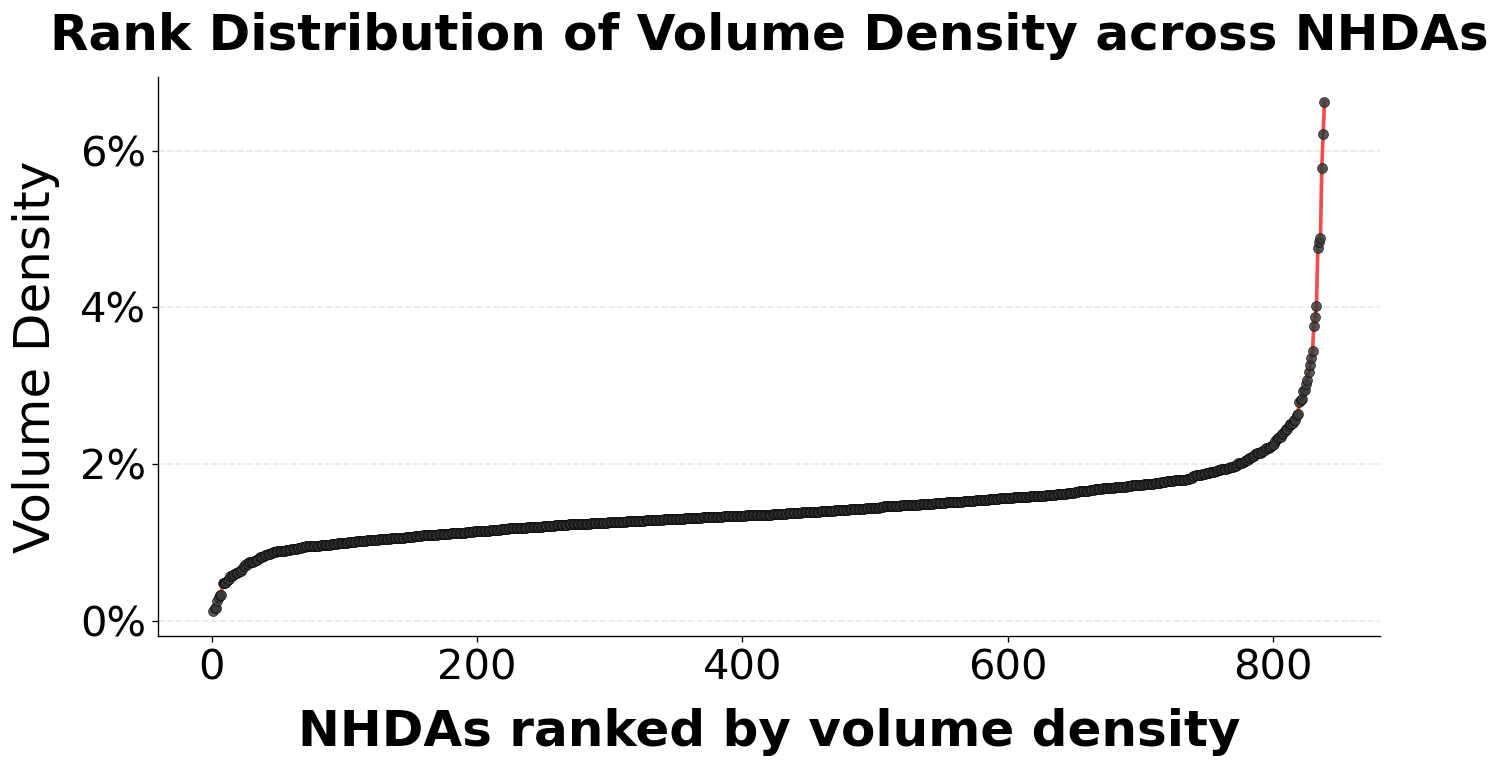

In [4]:
# Compact + cleaner rank plot of built-up ratios across NHDAs
plot_df = (
    gdf_nhda[["nhda_building_volume_density"]]
    .rename(columns={"nhda_building_volume_density": "volume_density"})
    .dropna()
    .sort_values("volume_density")
    .reset_index(drop=True)
)
plot_df["rank"] = np.arange(1, len(plot_df) + 1)

fig, ax = plt.subplots(figsize=(11.7, 6.5), dpi=120)



ax.scatter(
    plot_df["rank"],
    plot_df["volume_density"],
    s=36,
    color="#3a3a3a",
    alpha=0.85,
    edgecolors="black",
    linewidths=0.35,
    zorder=3,
)
ax.plot(
    plot_df["rank"],
    plot_df["volume_density"],
    color="#f03a3a",
    linewidth=2.2,
    alpha=0.9,
    zorder=2,
)
ax.set_xlabel("NHDAs ranked by volume density", fontsize=30, fontweight="bold", labelpad=12)
ax.set_ylabel("Volume Density", fontsize=30, labelpad=12)
ax.set_title("Rank Distribution of Volume Density across NHDAs", fontsize=30, fontweight="bold", pad=16)
ax.tick_params(axis="both", labelsize=25)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
ax.grid(axis="y", linestyle="--", alpha=0.28, linewidth=1.0, zorder=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ax.text(
#     0.01,
#     0.98,
#     f"n={len(plot_df)} | mean={plot_df['built_up_ratio'].mean():.1f}% | median={plot_df['built_up_ratio'].median():.1f}%",
#     transform=ax.transAxes,
#     ha="left",
#     va="top",
#     fontsize=16,
#     fontweight="bold",
#     color="#222222",
#     bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=3),
# )

fig.tight_layout()

out_scatter = output_dir / "rank_distribution_volume_density.jpg"
plt.savefig(out_scatter, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()